In [72]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [73]:
n = 50
a = np.zeros((n, n))

a[4:45, 4:45] = 1
a[9:40, 9:40] = 0


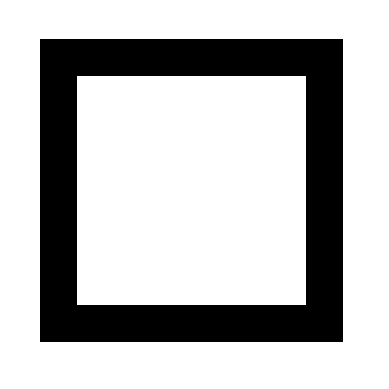

In [74]:
def draw(a):
    plt.imshow(a, cmap='Greys', interpolation='nearest')
    # plt.imshow(a, interpolation='nearest')
    plt.axis('off')
    plt.show()

def draw_grb(a):
    plt.imshow(a)
    plt.axis('off')
    plt.show()

draw(a)

In [110]:
M1 = np.array([
    [-1, -1, -1],
    [-1, 9, -1],
    [-1, -1, -1]
])

M2 = np.array([
    [-1, -1, -1, -1, -1],
    [-1, 0, 0, 0, -1],
    [-1, 0, 10, 0, -1],
    [-1, 0, 0, 0, -1],
    [-1, -1, -1, -1, -1]
])

M3 = np.array([
    [-1, 0, -1],
    [0, -1, 0],
    [-1, 0, -1]
])

In [111]:
def conv(a, M):
    m, n = a.shape
    k, _ = M.shape

    res = np.zeros((m-k+1, n-k+1))

    for i in range(m-k+1):
        for j in range(n-k+1):
            res[i, j] = (a[i:i+k, j:j+k]*M).sum()

    return res

def conv_max(a, k=2):
    m, n = a.shape
    res = np.zeros((m-k+1, n-k+1))

    for i in range(m-k+1):
        for j in range(n-k+1):
            res[i, j] = (a[i:i+k, j:j+k]).max()

    return res
    

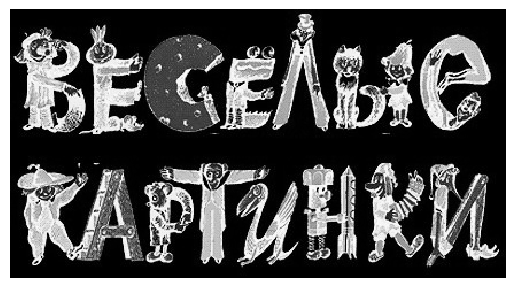

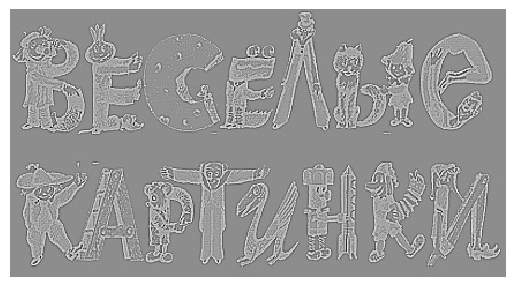

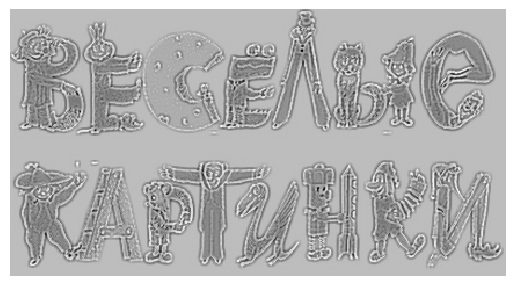

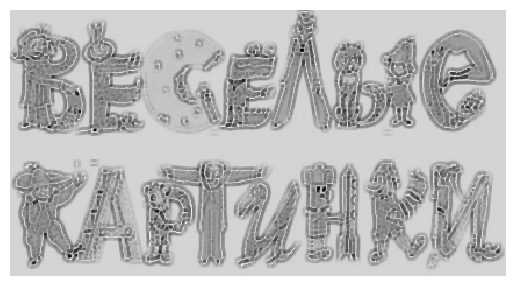

(None, None, None, None)

In [112]:
res1 = conv(a, M1)
res2 = conv(a, M2)
res3 = conv_max(res2, 2)
draw(a), draw(res1), draw(res2), draw(res3)

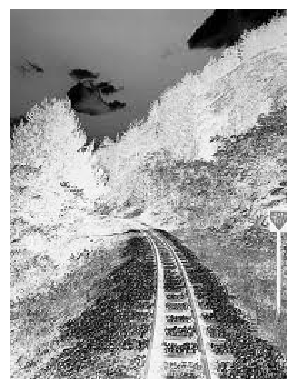

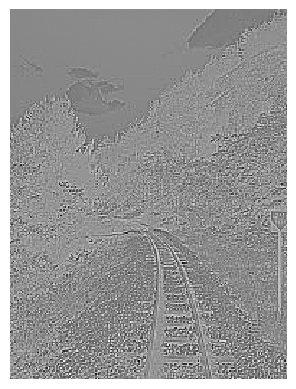

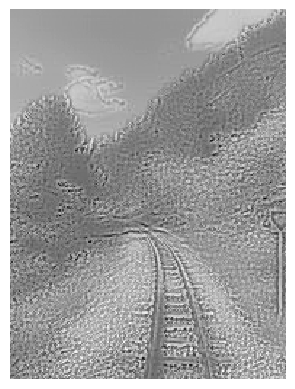

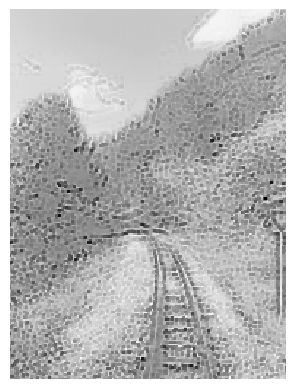

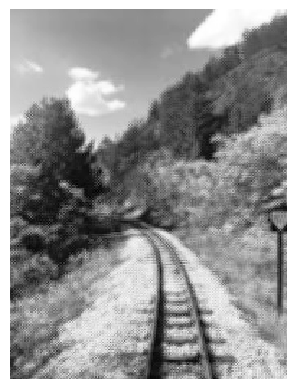

(None, None, None, None, None)

In [143]:
img_path = './railway.jpeg'
image = Image.open(img_path)
a = np.array(image.convert('L'))/255
# a = 1 - a

res1 = conv(a, M1)
res2 = conv(a, M2)
res3 = conv_max(res2, 2)
draw(a), draw(res1), draw(res2), draw(res3), draw(conv(a, M3))

In [144]:
M4 = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

M5 = M4.T

M6 = np.sqrt(M4**2 + M5**2)

M7 = np.array([
    [1, 1, 1, 1, 1],
    [1, -1, -1, -1, 1],
    [1, -1, 0, -1, 1],
    [1, -1, -1, -1, 1],
    [1, 1, 1, 1, 1]
])

M8 = np.array([
    [0, 1, 0],
    [1, 10, 1],
    [0, 1, 0]
])

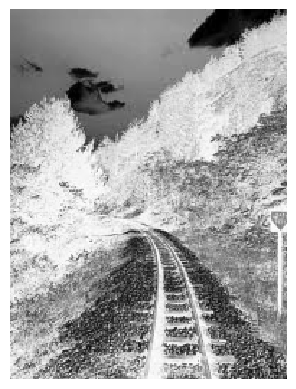

In [145]:
# draw(a), draw(conv(a, M4)), draw(conv(a, M5)), draw(conv(a, M6))
# draw(conv(a, M7))

draw(conv(a, M8))

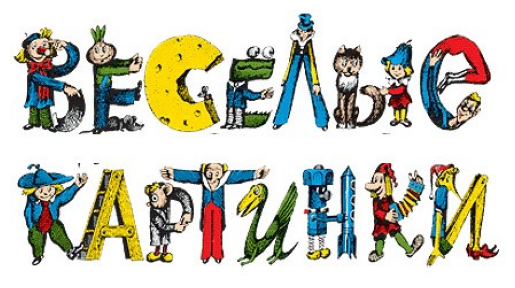

In [55]:
image = Image.open(img_path)
a = np.array(image)
draw_grb(a)

In [70]:
def f(p):
    return p.sum()/255/3

def watershed(img, teta):
    res = np.copy(img)
    m, n, _ = res.shape
    x = [i for i in range(n)]
    for i in range(m):
        y = []
        for j in range(n):
            y.append(f(img[i, j]))

        plt.plot(x,y)
        plt.plot(x, [teta for i in x])
        plt.show()
        while True:
            pass

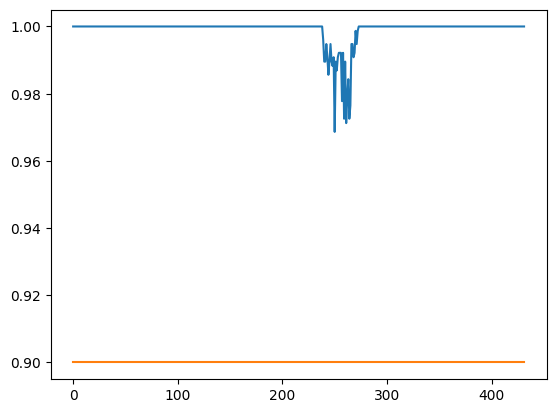

KeyboardInterrupt: 

In [71]:
watershed(a, 0.9)